# Análisis CLV completo — BG/NBD + Gamma-Gamma

Notebook principal del TFM. Integra los dos modelos del marco BTYD bayesiano y produce las estimaciones de CLV que constituyen el resultado principal del trabajo. Sigue literalmente la API y el flujo de trabajo recomendados en:

- **PyMC-Marketing — BG/NBD Model:** https://www.pymc-marketing.io/en/stable/notebooks/clv/bg_nbd.html
- **PyMC-Marketing — Gamma-Gamma Model:** https://www.pymc-marketing.io/en/stable/notebooks/clv/gamma_gamma.html

## Esquema conceptual

El CLV se descompone en dos factores independientes:

$$
\mathrm{CLV}_i(t) \;=\; \underbrace{\mathbb{E}[X_i(t) \mid \text{historial}]}_{\text{BG/NBD: transacciones futuras}} \;\times\; \underbrace{\mathbb{E}[\bar{Z}_i \mid \text{historial}]}_{\text{Gamma-Gamma: valor por transacción}}
$$

El modelo BG/NBD aporta las transacciones futuras esperadas y $P(\text{vivo})$; el Gamma-Gamma aporta el gasto medio por transacción condicionado a ser usuario recurrente. La independencia de los dos componentes —que es un supuesto formal del modelo Gamma-Gamma— se valida verificando que la correlación de Pearson entre `frequency` y `monetary_value` sea baja.

## Estructura del notebook

1. Carga del dataset y particiones
2. Ajuste del **BG/NBD** + diagnósticos + PPC
3. Ajuste del **Gamma-Gamma** + diagnósticos
4. **Predicciones individuales**: $P(\text{vivo})$, transacciones esperadas, gasto esperado
5. **CLV** a 1, 3 y 5 años con intervalos de credibilidad
6. **Segmentación**: CLV por tipo de título, cohorte y subpoblación joven
7. Conclusiones

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import xarray as xr
from pymc_marketing import clv

from config import (
    SEED, STATS, PARAMS_CALIBRATED, PRIORS, PRIORS_DEFAULT_KEY,
    MCMC_CONFIG, RFM_PATH, MODELS_DIR, priors_to_model_config,
    TARIFAS_POR_TITULO, SEMANAS_POR_MES,
)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"
sns.set_palette("deep")

RNG = np.random.default_rng(SEED)

# Directorio de figuras para el reporte (docs/figures, relativo a notebooks/)
FIG_DIR = Path("..") / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# El precio varía por tipo de título y se aplica en la sección 5 (CLV)
# vía config.TARIFAS_POR_TITULO.

# Cache de modelos ajustados:
#   - False (default): si existe el .nc cacheado, se carga; si no, se ajusta y guarda.
#   - True: ignora el cache y reajusta (necesario al cambiar datos o priors).
FORCE_REFIT = False

print(f"arviz {az.__version__}")
print(f"Prior por defecto:    {PRIORS_DEFAULT_KEY}")
print(f"Configuración MCMC:   {MCMC_CONFIG}")
print(f"Modelos cacheados en: {MODELS_DIR}")
print(f"Figuras del reporte:  {FIG_DIR}")
print(f"FORCE_REFIT:          {FORCE_REFIT}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


arviz 0.23.4
Prior por defecto:    elicited
Configuración MCMC:   {'draws': 2000, 'tune': 1500, 'chains': 4, 'target_accept': 0.9, 'nuts_sampler': 'nutpie', 'progressbar': True, 'random_seed': 42}
Modelos cacheados en: C:\Users\andre\OneDrive\Documentos\UGR\tfm-clv-transporte-granada\models
Figuras del reporte:  ..\docs\figures
FORCE_REFIT:          False


## 1. Carga del dataset y particiones

El Gamma-Gamma requiere usuarios con `frequency > 0` (al menos una transacción repetida). El BG/NBD admite todos. Trabajaremos con dos vistas del dataset:

- **`data_full`** — todos los usuarios. Entrada al BG/NBD.
- **`data_recurring`** — sólo usuarios con $x > 0$. Entrada al Gamma-Gamma.

Antes de pasar al Gamma-Gamma comprobamos un supuesto clave del modelo: que la correlación entre frequency y monetary_value sea baja (la referencia oficial usa el umbral $\approx 0.11$).

In [2]:
rfm = pd.read_csv(RFM_PATH)

data_full = rfm[["customer_id", "frequency", "recency", "T", "monetary_value"]].copy()
data_recurring = data_full.query("frequency > 0").copy()

print(f"Dataset cargado desde: {RFM_PATH}")
print(f"  Usuarios totales:        {len(data_full):,}")
print(f"  Usuarios recurrentes:    {len(data_recurring):,}  ({100*len(data_recurring)/len(data_full):.1f} %)")

# Verificación del supuesto Gamma-Gamma: correlación frequency / monetary baja
corr = data_recurring[["frequency", "monetary_value"]].corr().iloc[0, 1]
umbral = 0.30
estado = "✓" if abs(corr) < umbral else "✗"
print(f"\nSupuesto Gamma-Gamma — independencia frequency vs monetary:")
print(f"  Correlación de Pearson: {corr:+.3f}  (umbral aceptable: |ρ| < {umbral})  {estado}")

Dataset cargado desde: C:\Users\andre\OneDrive\Documentos\UGR\tfm-clv-transporte-granada\data\synthetic\rfm_full.csv
  Usuarios totales:        59,995
  Usuarios recurrentes:    59,123  (98.5 %)

Supuesto Gamma-Gamma — independencia frequency vs monetary:
  Correlación de Pearson: -0.129  (umbral aceptable: |ρ| < 0.3)  ✓


## 2. Modelo BG/NBD

### Recordatorio matemático

Mientras el usuario está "vivo" sus validaciones siguen un Poisson con tasa $\lambda_i$; tras cada período activo abandona con probabilidad $p_i$. La heterogeneidad poblacional es:

$$
\lambda_i \sim \mathrm{Gamma}(r,\, \alpha), \qquad p_i \sim \mathrm{Beta}(a,\, b)
$$

La verosimilitud individual para un usuario con historial $(x, t_x, T)$ es la suma compacta de Fader-Hardie-Lee (2005). `pymc-marketing` la implementa internamente.

In [3]:
CACHE_BGNBD = MODELS_DIR / f"bgnbd_{PRIORS_DEFAULT_KEY}_n{len(data_full)}.nc"

if CACHE_BGNBD.exists() and not FORCE_REFIT:
    print(f"Cargando modelo BG/NBD cacheado: {CACHE_BGNBD.name}")
    bgnbd = clv.BetaGeoModel.load(CACHE_BGNBD)
    bgnbd_cached = True
else:
    bgnbd = clv.BetaGeoModel(
        data=data_full,
        model_config=priors_to_model_config(PRIORS[PRIORS_DEFAULT_KEY])
    )
    bgnbd.build_model()
    bgnbd_cached = False
    if FORCE_REFIT:
        print("FORCE_REFIT activado : modelo nuevo, se ajustará en la siguiente celda")
    else:
        print(f"No hay cache para {CACHE_BGNBD.name} : modelo nuevo, se ajustará")

print("\nEstructura del modelo:")
print(bgnbd)

Cargando modelo BG/NBD cacheado: bgnbd_elicited_n59995.nc

Estructura del modelo:
BG/NBD
            alpha ~ Gamma(2.72, f())
      phi_dropout ~ Beta(1.35, 30)
    kappa_dropout ~ Gamma(3.23, f())
                r ~ Gamma(2.77, f())
                a ~ Deterministic(f(kappa_dropout, phi_dropout))
                b ~ Deterministic(f(kappa_dropout, phi_dropout))
recency_frequency ~ BetaGeoNBD(a, b, r, alpha, <constant>)


In [4]:
if bgnbd_cached:
    print(f"Modelo ya ajustado (cargado de {CACHE_BGNBD.name}) — saltando .fit()")
else:
    print(f"Ajustando BG/NBD sobre {len(data_full):,} usuarios con NUTS (nutpie)...")
    t0 = time.time()
    bgnbd.fit(**MCMC_CONFIG)
    dt = (time.time() - t0) / 60
    print(f"Fit completo en {dt:.1f} minutos. Guardando cache...")
    bgnbd.save(CACHE_BGNBD)
    print(f"Modelo guardado en {CACHE_BGNBD}")

Modelo ya ajustado (cargado de bgnbd_elicited_n59995.nc) — saltando .fit()


In [5]:
VARS_BG = ["r", "alpha", "a", "b"]
summary_bg = az.summary(bgnbd.idata, var_names=VARS_BG, hdi_prob=0.95, round_to=4)
print("Resumen posterior BG/NBD (HDI 95 %):")
print(summary_bg)

# Diagnósticos
n_div = int(bgnbd.idata.sample_stats["diverging"].sum())
print(f"\nDivergencias: {n_div}  {'✓' if n_div == 0 else '✗'}")
print("R̂:", "✓" if (summary_bg["r_hat"] < 1.01).all() else "✗")
print("ESS_bulk > 400:", "✓" if (summary_bg["ess_bulk"] > 400).all() else "✗")

Resumen posterior BG/NBD (HDI 95 %):
          mean      sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd   ess_bulk  \
r      13.2221  0.1009   13.0313    13.4217     0.0024   0.0017  1735.6395   
alpha  14.2637  0.1106   14.0506    14.4773     0.0027   0.0018  1732.3689   
a       0.2689  0.0028    0.2635     0.2744     0.0000   0.0000  4025.5503   
b      19.2472  0.4012   18.4814    20.0382     0.0078   0.0062  2682.5307   

        ess_tail   r_hat  
r      2189.9332  1.0016  
alpha  2158.0694  1.0019  
a      4525.3373  1.0019  
b      3066.1297  1.0025  

Divergencias: 0  ✓
R̂: ✓
ESS_bulk > 400: ✓


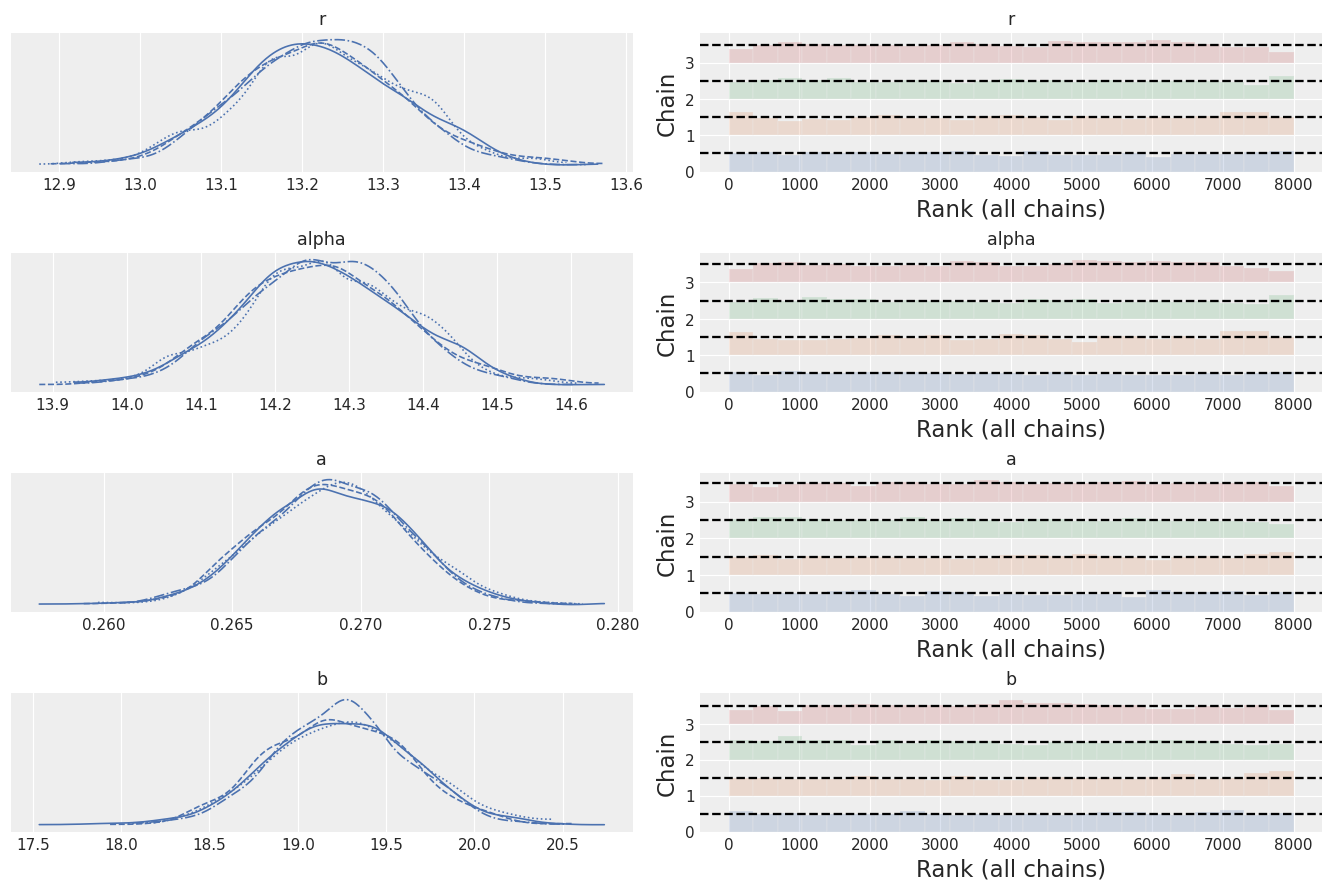

In [6]:
# Rank plots (rank_bars) — diagnóstico visual de mezcla del BG/NBD.
axes = az.plot_trace(
    bgnbd.idata,
    var_names=VARS_BG,
    compact=True,
    kind="rank_bars",
    backend_kwargs={"figsize": (12, 8), "layout": "constrained"},
)
fig = axes.ravel()[0].figure
fig.savefig(FIG_DIR / "rank_bgnbd.pdf")
fig.savefig(FIG_DIR / "rank_bgnbd.png", dpi=200)
plt.show()

## 2.5 Análisis predictivo del BG/NBD

Una vez ajustado y diagnosticado el modelo, lo usamos para responder las preguntas operativas del TFM. Siguiendo la referencia de `pymc-marketing`, mostramos tres análisis por usuario:

1. **Transacciones esperadas** $\mathbb{E}[X(t)]$ sobre un horizonte futuro de 90 semanas, con bandas de incertidumbre.
2. **$P(\text{vivo})$** sobre el mismo horizonte — el decaimiento de la probabilidad posterior de seguir activo a medida que pasa el tiempo sin nuevas validaciones.
3. **Probabilidad de cero transacciones** en los próximos $t$ períodos.

Para que las figuras sean legibles en el reporte, estos análisis se ilustran sobre un **conjunto reducido de usuarios representativos** (arquetipos), no sobre toda la base. La celda de texto siguiente justifica formalmente por qué un número pequeño de arquetipos es suficiente para representar el rango completo de comportamientos.

### ¿Por qué bastan cuatro usuarios representativos?

Las cantidades posteriores por usuario que graficamos —$P(\text{vivo})$ y $\mathbb{E}[X(t)]$— dependen del historial **solo a través del estadístico suficiente** $(x, t_x, T)$ (factorización de la verosimilitud BG/NBD). Conviene reparametrizar con la **dormancia** $d = T - t_x$. Para la probabilidad de permanencia, condicional a los parámetros poblacionales,

$$
P(\text{vivo}\mid x, t_x, T) \;=\; \left[\,1 + \frac{a}{b+x-1}\left(\frac{\alpha+T}{\alpha+t_x}\right)^{r+x}\right]^{-1},
\qquad x>0 .
$$

Escribiendo el cociente como $\dfrac{\alpha+T}{\alpha+t_x} = 1 + \dfrac{d}{\alpha+t_x} \ge 1$, se ve que es **creciente en la dormancia $d$**; por tanto el corchete crece con $d$ y $P(\text{vivo})$ es **monótona decreciente en $d$**. Análogamente, el exponente $r+x$ amplifica el efecto al crecer la frecuencia $x$.

En consecuencia, la familia de curvas $\{P(\text{vivo})\}$ está **ordenada** por $(x, d)$: cualquier usuario con frecuencia y dormancia intermedias produce una curva **acotada** entre las de los usuarios extremos. Basta entonces con seleccionar los **cuatro vértices** del rectángulo de comportamiento

$$
\{x_{\text{bajo}}, x_{\text{alto}}\} \times \{d_{\text{baja}}, d_{\text{alta}}\}
$$

para que las curvas mostradas **envuelvan** todo el rango de comportamientos plausibles; añadir más usuarios solo rellenaría el interior, sin ampliar el rango. Este es un argumento de **representatividad estructural** (no estadística): el objetivo de estas figuras es ilustrar el espectro de dinámicas, no estimar una cantidad poblacional —para eso se usa la muestra de análisis de la Sección 4, cuya suficiencia se justifica por separado.

In [7]:
# Selección de 4 ARQUETIPOS representativos: los vértices del rectángulo de
# comportamiento (frecuencia × dormancia). Por el argumento de monotonía de
# la celda anterior, las curvas de estos 4 usuarios envuelven el rango completo.
# Se elige, para cada vértice objetivo, el usuario real más cercano en el
# espacio de percentiles (garantiza que existe y es representativo).

rfm_arq = rfm.copy()
rfm_arq["dormancia"] = rfm_arq["T"] - rfm_arq["recency"]
rfm_arq["f_q"] = rfm_arq["frequency"].rank(pct=True)
rfm_arq["d_q"] = rfm_arq["dormancia"].rank(pct=True)

# (percentil de frecuencia, percentil de dormancia) objetivo de cada arquetipo
ARQUETIPOS = {
    "Ocasional reciente": (0.20, 0.10),
    "Ocasional dormido":  (0.20, 0.90),
    "Intensivo activo":   (0.90, 0.10),
    "Intensivo dormido":  (0.90, 0.90),
}

filas = []
for nombre, (fq, dq) in ARQUETIPOS.items():
    dist2 = (rfm_arq["f_q"] - fq) ** 2 + (rfm_arq["d_q"] - dq) ** 2
    row = rfm_arq.loc[dist2.idxmin(),
                      ["customer_id", "frequency", "recency", "T", "monetary_value"]].copy()
    row["arquetipo"] = nombre
    filas.append(row)

sample_customers = pd.DataFrame(filas).reset_index(drop=True)

print("Arquetipos representativos seleccionados:")
print(sample_customers[["arquetipo", "customer_id", "frequency", "recency", "T"]]
      .to_string(index=False))

Arquetipos representativos seleccionados:
         arquetipo    customer_id  frequency  recency     T
Ocasional reciente USR_2025_00227         20     50.0  51.0
 Ocasional dormido USR_2018_03320         23     28.0 415.0
  Intensivo activo USR_2018_00047        384    415.0 416.0
 Intensivo dormido USR_2018_00733        209    212.0 416.0


C:\Users\andre\AppData\Local\Temp\ipykernel_36652\2188302757.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


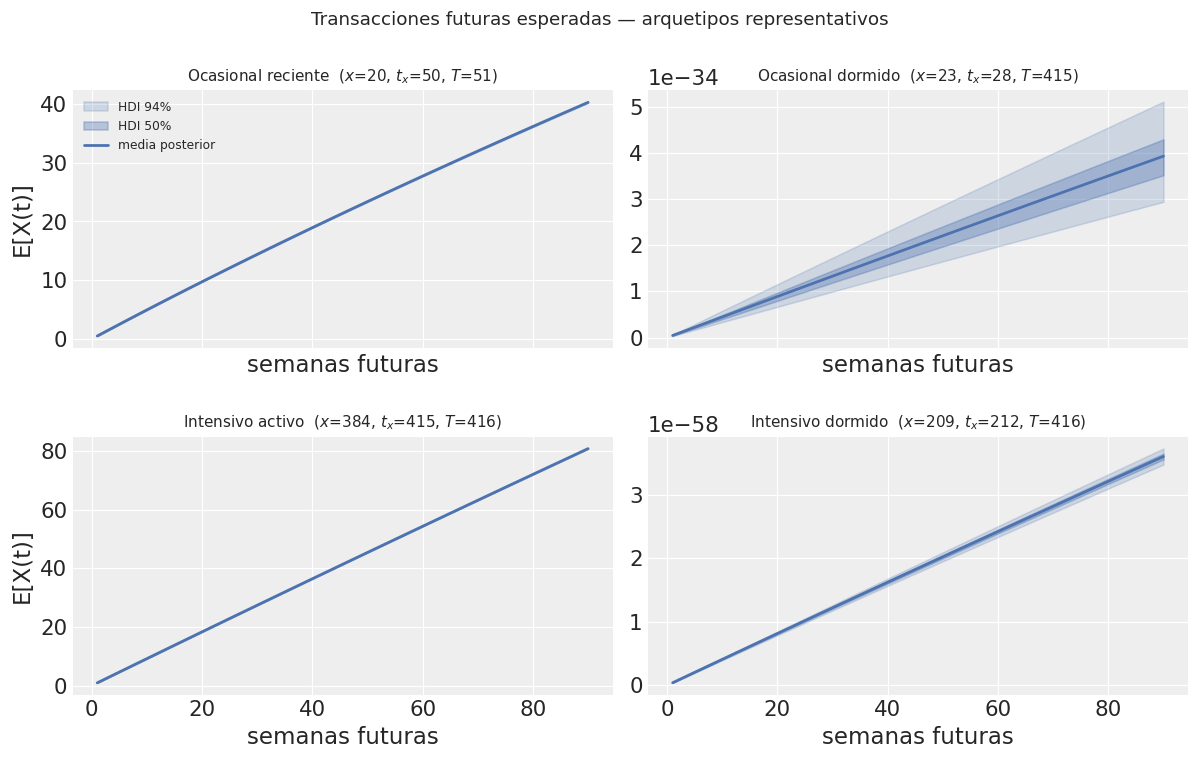

In [8]:
# Trayectoria de E[X(t)] para t = 1..90 semanas sobre los 4 arquetipos.
steps = 90
t_grid = np.arange(1, steps + 1)
base = sample_customers[["customer_id", "frequency", "recency", "T"]].copy()

exp_purchases_steps = xr.concat(
    [bgnbd.expected_purchases(data=base, future_t=t) for t in t_grid],
    dim="future_t",
).assign_coords(future_t=t_grid)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, (_, cust) in zip(axes.ravel(), sample_customers.iterrows()):
    curve = exp_purchases_steps.sel(customer_id=cust["customer_id"])
    mean = curve.mean(dim=("chain", "draw"))
    lo94 = curve.quantile(0.03, dim=("chain", "draw"))
    hi94 = curve.quantile(0.97, dim=("chain", "draw"))
    lo50 = curve.quantile(0.25, dim=("chain", "draw"))
    hi50 = curve.quantile(0.75, dim=("chain", "draw"))

    ax.fill_between(t_grid, lo94, hi94, alpha=0.20, color="C0", label="HDI 94%")
    ax.fill_between(t_grid, lo50, hi50, alpha=0.35, color="C0", label="HDI 50%")
    ax.plot(t_grid, mean, color="C0", lw=1.8, label="media posterior")
    ax.set_title(f"{cust['arquetipo']}  "
                 f"($x$={cust['frequency']}, $t_x$={cust['recency']:.0f}, $T$={cust['T']:.0f})",
                 fontsize=10)
    ax.set_xlabel("semanas futuras")

axes[0, 0].set_ylabel("E[X(t)]")
axes[1, 0].set_ylabel("E[X(t)]")
axes[0, 0].legend(fontsize=8, loc="upper left")
plt.suptitle("Transacciones futuras esperadas — arquetipos representativos", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "expected_purchases_arquetipos.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "expected_purchases_arquetipos.png", dpi=200, bbox_inches="tight")
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_36652\3917539073.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


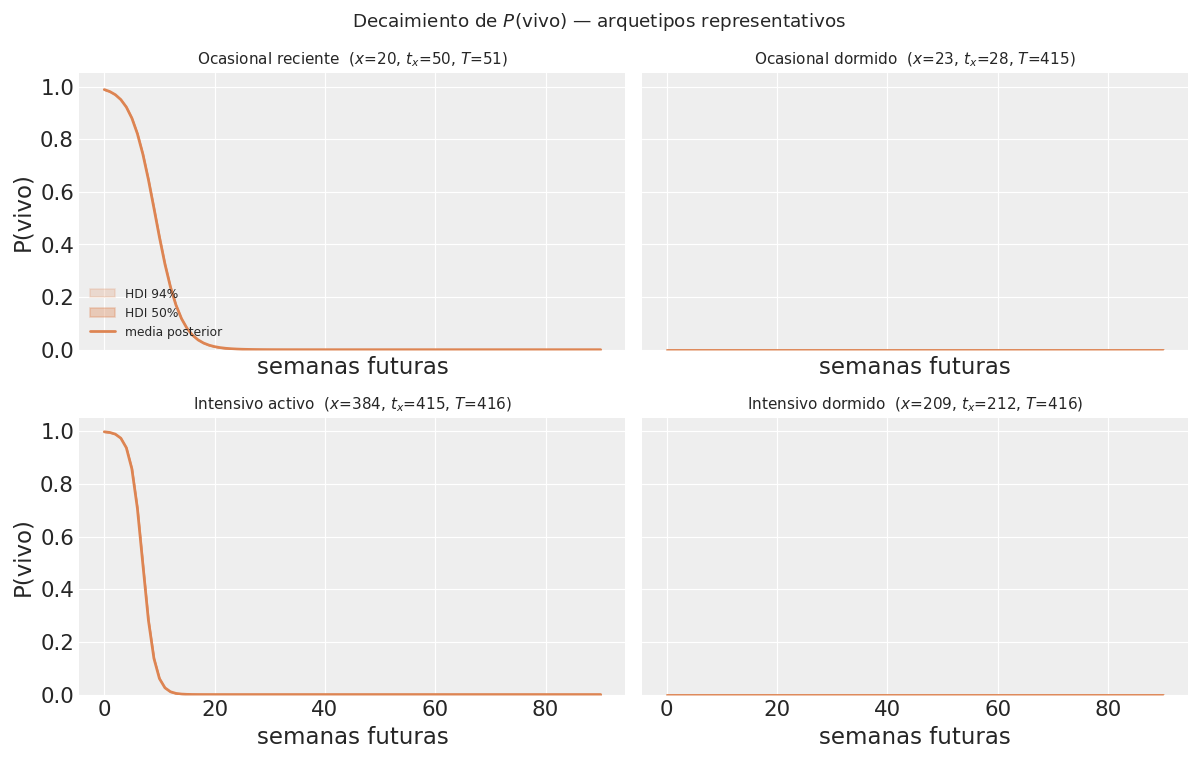

In [9]:
# P(vivo) en horizonte futuro sobre los 4 arquetipos: avanzamos T sin nueva
# actividad, lo que modela la erosión de la confianza en que el usuario sigue activo.
steps = 90
t_grid = np.arange(0, steps + 1)
base = sample_customers[["customer_id", "frequency", "recency", "T"]].copy()

p_alive_steps = xr.concat(
    [bgnbd.expected_probability_alive(data=base.assign(T=base["T"] + t)) for t in t_grid],
    dim="future_t",
).assign_coords(future_t=t_grid)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
for ax, (_, cust) in zip(axes.ravel(), sample_customers.iterrows()):
    curve = p_alive_steps.sel(customer_id=cust["customer_id"])
    mean = curve.mean(dim=("chain", "draw"))
    lo94 = curve.quantile(0.03, dim=("chain", "draw"))
    hi94 = curve.quantile(0.97, dim=("chain", "draw"))
    lo50 = curve.quantile(0.25, dim=("chain", "draw"))
    hi50 = curve.quantile(0.75, dim=("chain", "draw"))

    ax.fill_between(t_grid, lo94, hi94, alpha=0.20, color="C1", label="HDI 94%")
    ax.fill_between(t_grid, lo50, hi50, alpha=0.35, color="C1", label="HDI 50%")
    ax.plot(t_grid, mean, color="C1", lw=1.8, label="media posterior")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{cust['arquetipo']}  "
                 f"($x$={cust['frequency']}, $t_x$={cust['recency']:.0f}, $T$={cust['T']:.0f})",
                 fontsize=10)
    ax.set_xlabel("semanas futuras")

axes[0, 0].set_ylabel("P(vivo)")
axes[1, 0].set_ylabel("P(vivo)")
axes[0, 0].legend(fontsize=8, loc="lower left")
plt.suptitle("Decaimiento de $P(\\text{vivo})$ — arquetipos representativos", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "p_alive_arquetipos.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "p_alive_arquetipos.png", dpi=200, bbox_inches="tight")
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_36652\2600002174.py:53: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


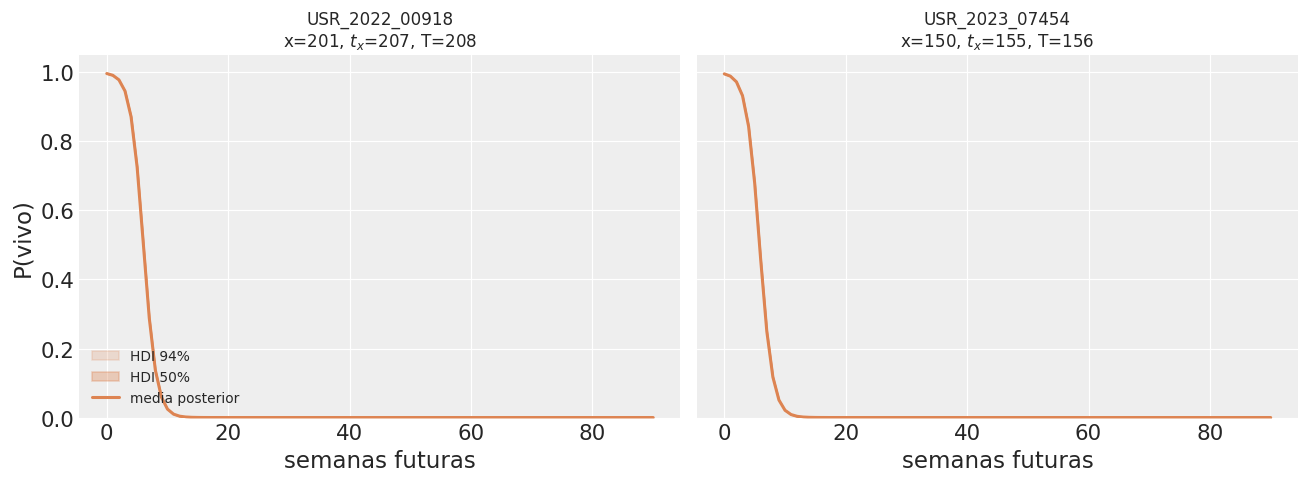

In [10]:
# ─────────────────────────────────────────────────────────────
# P(vivo) para dos usuarios concretos, uno al lado del otro
# ─────────────────────────────────────────────────────────────
from pathlib import Path

ids_destacados = ["USR_2022_00918", "USR_2023_07454"]

# Seleccionar desde el CSV completo (rfm), no desde data_full,
# y respetar el orden pedido.
sel = rfm[rfm["customer_id"].isin(ids_destacados)].copy()
sel = sel.set_index("customer_id").loc[ids_destacados].reset_index()
assert len(sel) == 2, "Alguno de los dos usuarios no se encontró en rfm"

# Trayectoria de P(vivo) avanzando T sin nueva actividad
steps = 90
t_grid = np.arange(0, steps + 1)
p_alive_list = []
for t in t_grid:
    fut = sel.copy()
    fut["T"] = fut["T"] + t
    p_alive_list.append(
        bgnbd.expected_probability_alive(
            data=fut[["customer_id", "frequency", "recency", "T"]]
        )
    )
p_alive_traj = xr.concat(p_alive_list, dim="future_t").assign_coords(future_t=t_grid)

# Plot 1x2
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (_, cust) in zip(axes, sel.iterrows()):
    curve = p_alive_traj.sel(customer_id=cust["customer_id"])
    mean = curve.mean(dim=("chain", "draw"))
    lo94 = curve.quantile(0.03, dim=("chain", "draw"))
    hi94 = curve.quantile(0.97, dim=("chain", "draw"))
    lo50 = curve.quantile(0.25, dim=("chain", "draw"))
    hi50 = curve.quantile(0.75, dim=("chain", "draw"))

    ax.fill_between(t_grid, lo94, hi94, alpha=0.20, color="C1", label="HDI 94%")
    ax.fill_between(t_grid, lo50, hi50, alpha=0.35, color="C1", label="HDI 50%")
    ax.plot(t_grid, mean, color="C1", lw=2, label="media posterior")

    ax.set_ylim(0, 1.05)
    ax.set_xlabel("semanas futuras")
    ax.set_title(
        f"{cust['customer_id']}\n"
        f"x={cust['frequency']}, $t_x$={cust['recency']:.0f}, T={cust['T']:.0f}",
        fontsize=11,
    )

axes[0].set_ylabel("P(vivo)")
axes[0].legend(fontsize=9, loc="lower left")
#plt.suptitle("Decaimiento de $P(\\text{vivo})$ ", fontsize=12)
plt.tight_layout()

# Guardar para el reporte
fig_dir = Path("..") / "docs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "p_alive_dos_usuarios.pdf", bbox_inches="tight")
fig.savefig(fig_dir / "p_alive_dos_usuarios.png", dpi=200, bbox_inches="tight")
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_36652\2680853223.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


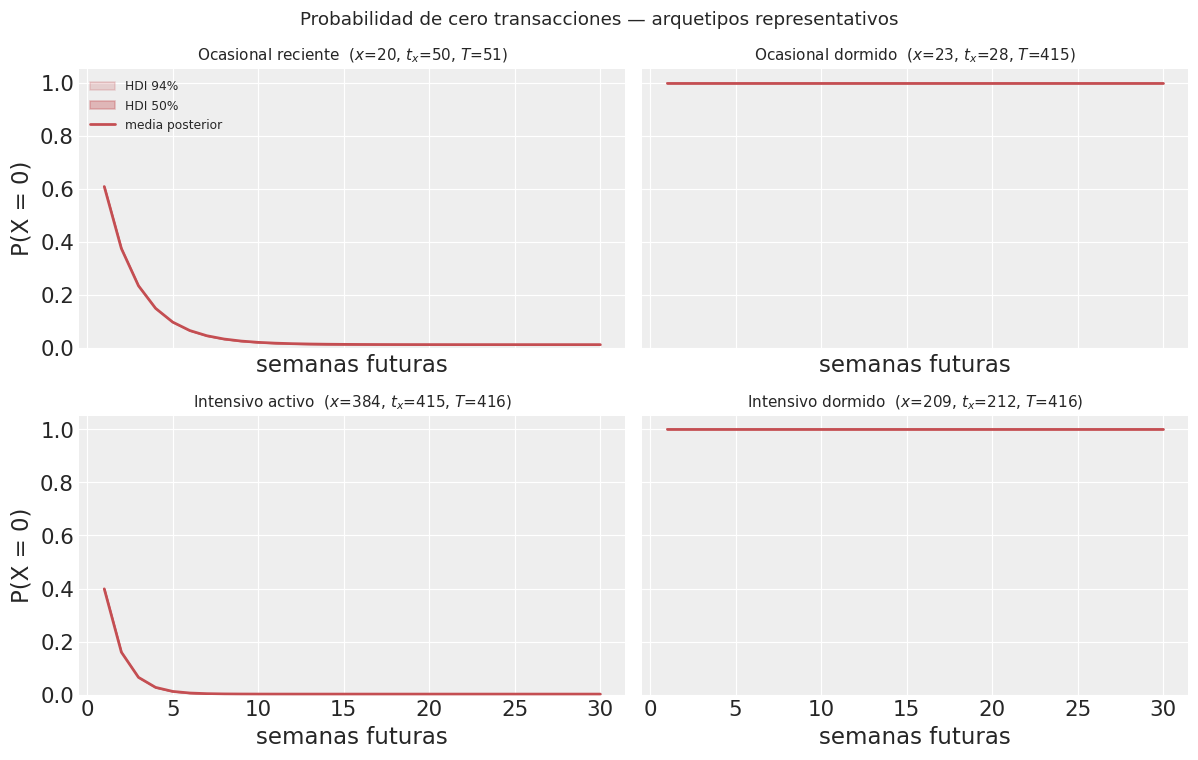

In [11]:
# Probabilidad de NO realizar ninguna transacción en las próximas t semanas,
# sobre los 4 arquetipos. Es la dual de E[X(t)].
steps = 30
t_grid = np.arange(1, steps + 1)
base = sample_customers[["customer_id", "frequency", "recency", "T"]].copy()

p_no_purchase = xr.concat(
    [bgnbd.expected_probability_no_purchase(data=base, t=t) for t in t_grid],
    dim="future_t",
).assign_coords(future_t=t_grid)

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
for ax, (_, cust) in zip(axes.ravel(), sample_customers.iterrows()):
    curve = p_no_purchase.sel(customer_id=cust["customer_id"])
    mean = curve.mean(dim=("chain", "draw"))
    lo94 = curve.quantile(0.03, dim=("chain", "draw"))
    hi94 = curve.quantile(0.97, dim=("chain", "draw"))
    lo50 = curve.quantile(0.25, dim=("chain", "draw"))
    hi50 = curve.quantile(0.75, dim=("chain", "draw"))

    ax.fill_between(t_grid, lo94, hi94, alpha=0.20, color="C3", label="HDI 94%")
    ax.fill_between(t_grid, lo50, hi50, alpha=0.35, color="C3", label="HDI 50%")
    ax.plot(t_grid, mean, color="C3", lw=1.8, label="media posterior")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{cust['arquetipo']}  "
                 f"($x$={cust['frequency']}, $t_x$={cust['recency']:.0f}, $T$={cust['T']:.0f})",
                 fontsize=10)
    ax.set_xlabel("semanas futuras")

axes[0, 0].set_ylabel("P(X = 0)")
axes[1, 0].set_ylabel("P(X = 0)")
axes[0, 0].legend(fontsize=8, loc="upper left")
plt.suptitle("Probabilidad de cero transacciones — arquetipos representativos", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "p_no_purchase_arquetipos.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "p_no_purchase_arquetipos.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Modelo Gamma-Gamma

### Recordatorio matemático

Sea $z_{ij}$ el gasto del usuario $i$ en su transacción $j$. El modelo Gamma-Gamma supone:

$$
z_{ij} \mid \nu_i \sim \mathrm{Gamma}(p,\, \nu_i), \qquad \nu_i \sim \mathrm{Gamma}(q,\, \gamma)
$$

donde $\nu_i$ es el parámetro de "escala" individual y $(p, q, \gamma)$ son hiperparámetros poblacionales. La media marginal del gasto por transacción del usuario $i$ es:

$$
\mathbb{E}[z_i \mid \bar{z}_i, x_i] \;=\; \frac{p\,\gamma + \bar{z}_i\,x_i\,p}{x_i\,p + q - 1}
$$

Se ajusta sólo sobre `data_recurring` porque la fórmula requiere al menos una observación de gasto por usuario.

In [12]:
CACHE_GG = MODELS_DIR / f"gg_n{len(data_recurring)}.nc"

if CACHE_GG.exists() and not FORCE_REFIT:
    print(f"Cargando modelo Gamma-Gamma cacheado: {CACHE_GG.name}")
    gg = clv.GammaGammaModel.load(CACHE_GG)
else:
    gg = clv.GammaGammaModel(data=data_recurring)
    gg.build_model()

    print(f"Ajustando Gamma-Gamma sobre {len(data_recurring):,} usuarios recurrentes...")
    t0 = time.time()
    gg.fit(**MCMC_CONFIG)
    dt = (time.time() - t0) / 60
    print(f"Fit completo en {dt:.1f} minutos. Guardando cache...")
    gg.save(CACHE_GG)
    print(f"✓ Modelo guardado en {CACHE_GG}")

Cargando modelo Gamma-Gamma cacheado: gg_n59123.nc


In [13]:
print(gg)

Gamma-Gamma Model (Mean Transactions)
         p ~ HalfFlat()
         q ~ HalfFlat()
         v ~ HalfFlat()
likelihood ~ Potential(f(q, p, v))


In [14]:
VARS_GG = ["p", "q", "v"]
summary_gg = az.summary(gg.idata, var_names=VARS_GG, hdi_prob=0.95, round_to=4)
print("Resumen posterior Gamma-Gamma (HDI 95 %):")
print(summary_gg)

n_div_gg = int(gg.idata.sample_stats["diverging"].sum())
print(f"\nDivergencias: {n_div_gg}  {'✓' if n_div_gg == 0 else '✗'}")

Resumen posterior Gamma-Gamma (HDI 95 %):
     mean      sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd   ess_bulk  \
p  5.5826  0.2851    5.0270     6.1431     0.0106   0.0072   730.8791   
q  9.4884  0.0599    9.3777     9.6126     0.0012   0.0009  2499.1494   
v  6.3519  0.3403    5.6990     7.0216     0.0126   0.0080   727.5108   

    ess_tail   r_hat  
p   681.9449  1.0021  
q  2206.6897  1.0012  
v   739.9511  1.0022  

Divergencias: 0  ✓


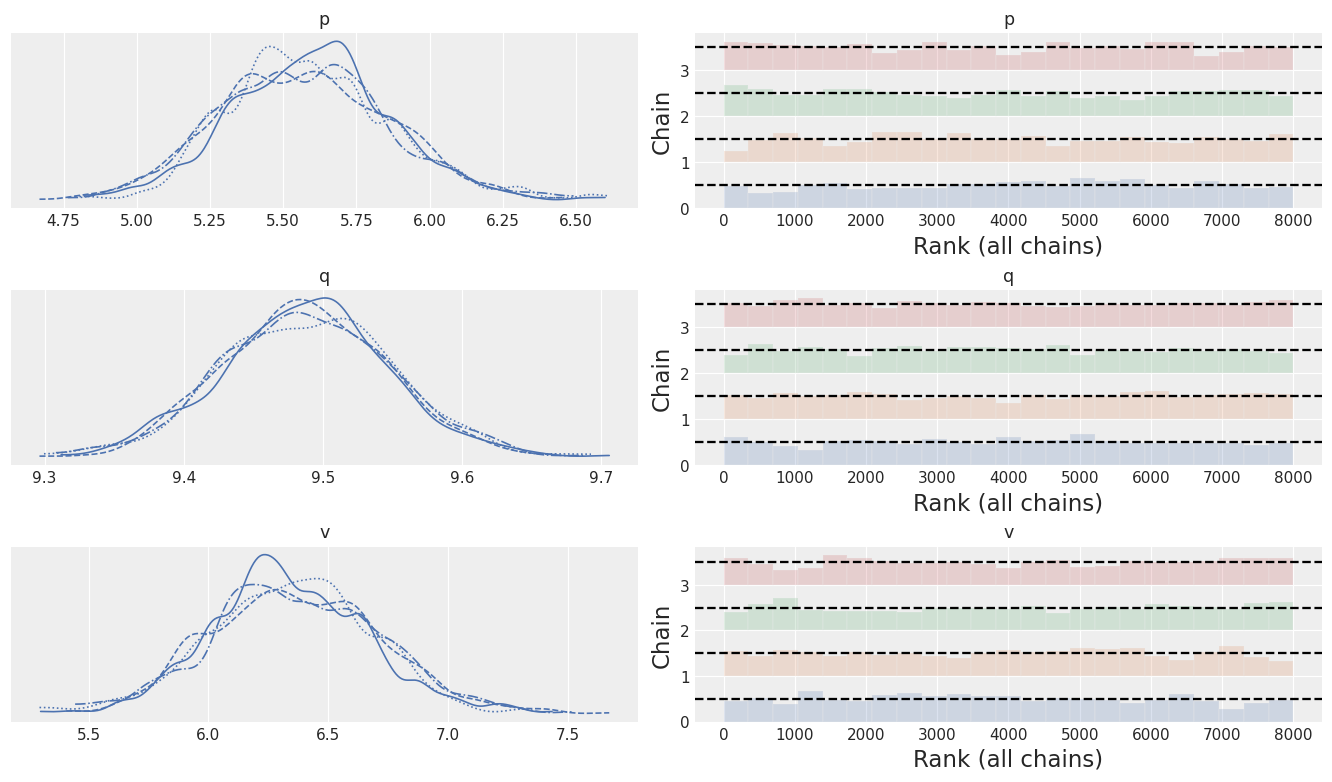

In [15]:
# Rank plots (rank_bars) — diagnóstico visual de mezcla del Gamma-Gamma.
axes = az.plot_trace(
    gg.idata,
    var_names=VARS_GG,
    compact=True,
    kind="rank_bars",
    backend_kwargs={"figsize": (12, 7), "layout": "constrained"},
)
fig = axes.ravel()[0].figure
fig.savefig(FIG_DIR / "rank_gg.pdf")
fig.savefig(FIG_DIR / "rank_gg.png", dpi=200)
plt.show()

## 4. Predicciones individuales

Tres cantidades por usuario, cada una con su distribución posterior completa:

1. $P(\text{vivo} \mid x, t_x, T)$ — probabilidad posterior de seguir activo hoy.
2. $\mathbb{E}[X_i(t)]$ — número de validaciones esperadas en los próximos $t$ semanas (de BG/NBD).
3. $\mathbb{E}[\bar{z}_i]$ — gasto esperado por transacción (de Gamma-Gamma).

### Suficiencia de la muestra de análisis

Evaluar las predicciones por usuario sobre los $\sim$60.000 usuarios es costoso, por lo que las cantidades poblacionales (distribución de $P(\text{vivo})$, distribución del CLV, medias por segmento) se estiman sobre una **submuestra estratificada** de tamaño $n \approx 10.000$. Es importante subrayar que las posteriores de los parámetros poblacionales $(r,\alpha,a,b,p,q,\gamma)$ **no** se reestiman aquí: se ajustaron sobre la base completa con MCMC. La submuestra solo sirve para caracterizar la **distribución empírica** de las cantidades derivadas a nivel de usuario. La pregunta es entonces: ¿es $n\approx 10.000$ suficiente para estimar esa distribución con precisión?

**Media de cantidades acotadas.** Para $P(\text{vivo}) \in [0,1]$, la desigualdad de Hoeffding acota la desviación de la media muestral $\widehat{\mu}_n$ respecto de la poblacional $\mu$:
$$
\Prob\!\left(\lvert \widehat{\mu}_n - \mu\rvert \ge \varepsilon\right) \le 2\exp(-2n\varepsilon^2).
$$
Igualando el lado derecho a $0{,}05$ con $n = 10.000$ se obtiene $\varepsilon = \sqrt{\ln(40)/(2n)} \approx 0{,}0136$. Es decir, la media poblacional de $P(\text{vivo})$ se estima con un error inferior a $\pm 0{,}014$ con confianza del $95\,\%$.

**Distribución completa (cuantiles del CLV).** Para los cuantiles del CLV —mediana, $P_5$, $P_{95}$ de la tabla— el control debe ser sobre toda la función de distribución. La desigualdad de Dvoretzky–Kiefer–Wolfowitz (con la constante óptima de Massart) acota la distancia uniforme entre la distribución empírica $F_n$ y la verdadera $F$:
$$
\Prob\!\left(\sup_{x}\lvert F_n(x) - F(x)\rvert > \varepsilon\right) \le 2\exp(-2n\varepsilon^2).
$$
Con $n = 10.000$ y confianza del $95\,\%$, $\varepsilon \approx 0{,}0136$: la distribución empírica del CLV está uniformemente a menos de $1{,}4$ puntos porcentuales de la verdadera, lo que garantiza que los cuantiles reportados son precisos a ese orden.

**Estratificación y corrección por población finita.** El muestreo estratificado proporcional por $(\text{tipo\_titulo} \times \text{es\_joven})$ preserva la composición de segmentos y produce un estimador con varianza **menor o igual** que el muestreo aleatorio simple, por lo que las cotas anteriores son conservadoras. Además, al muestrear sin reemplazo $n\approx 10.000$ de $N\approx 60.000$, la corrección por población finita reduce el error estándar en un factor $\sqrt{(N-n)/(N-1)} \approx 0{,}91$.

**Conclusión.** $n\approx 10.000$ es holgadamente suficiente: el factor limitante de la precisión de las estimaciones de CLV no es el submuestreo de usuarios, sino la anchura de las posteriores de los parámetros del modelo, que se propaga a través de las 8.000 muestras MCMC.

In [16]:
# Sampleo estratificado proporcional por (tipo_titulo, es_joven) → preserva
# la mezcla del dataset completo, así que la segmentación sigue siendo válida.
# Las posteriores poblacionales de (r, alpha, a, b) NO se ven afectadas;
# esas siguen ajustadas sobre los 60k del modelo MCMC.

N_ANALYSIS = 10000

estrato = (rfm["tipo_titulo"].astype(str) + "_" + rfm["es_joven"].astype(str))
data_analysis = (
    rfm.assign(_estrato=estrato)
       .groupby("_estrato", group_keys=False)
       .apply(lambda d: d.sample(
           n=max(1, int(round(N_ANALYSIS * len(d) / len(rfm)))),
           random_state=SEED))
       [["customer_id", "frequency", "recency", "T", "monetary_value"]]
       .reset_index(drop=True)
)
data_recurring_analysis = data_analysis.query("frequency > 0").reset_index(drop=True)

print(f"Muestra de análisis: {len(data_analysis):,} usuarios "
      f"({100*len(data_analysis)/len(data_full):.1f}% del total)")
print(f"  Recurrentes:        {len(data_recurring_analysis):,}")

print("\nProporciones preservadas (population vs muestra):")
ids_sample = set(data_analysis["customer_id"])
rfm_sample = rfm[rfm["customer_id"].isin(ids_sample)]
for col in ["tipo_titulo", "es_joven"]:
    full_pct = rfm[col].value_counts(normalize=True).sort_index()
    samp_pct = rfm_sample[col].value_counts(normalize=True).sort_index()
    for k in full_pct.index:
        print(f"  {col} = {str(k):20s}: full={full_pct[k]:.3f}   muestra={samp_pct[k]:.3f}")

Muestra de análisis: 10,000 usuarios (16.7% del total)
  Recurrentes:        9,866

Proporciones preservadas (population vs muestra):
  tipo_titulo = bono_30_dias        : full=0.019   muestra=0.019
  tipo_titulo = monedero_metro      : full=0.130   muestra=0.130
  tipo_titulo = ocasional           : full=0.061   muestra=0.061
  tipo_titulo = tarjeta_consorcio   : full=0.790   muestra=0.790
  es_joven = False               : full=0.874   muestra=0.874
  es_joven = True                : full=0.126   muestra=0.126


In [17]:
p_alive = bgnbd.expected_probability_alive(data=data_analysis)

p_alive_med = p_alive.median(dim=("chain", "draw")).to_pandas()
p_alive_lo  = p_alive.quantile(0.025, dim=("chain", "draw")).to_pandas()
p_alive_hi  = p_alive.quantile(0.975, dim=("chain", "draw")).to_pandas()

print(f"P(vivo) calculado sobre muestra de {len(data_analysis):,} usuarios.\n")
print(f"  Mediana poblacional: {p_alive_med.median():.3f}")
print(f"  Ancho medio HDI 95%: {(p_alive_hi - p_alive_lo).mean():.3f}")
print(f"  Usuarios 'muertos' (P_alive_med < 0.1):  {(p_alive_med < 0.1).sum():,}")
print(f"  Usuarios 'vivos'    (P_alive_med > 0.9): {(p_alive_med > 0.9).sum():,}")

P(vivo) calculado sobre muestra de 10,000 usuarios.

  Mediana poblacional: 0.990
  Ancho medio HDI 95%: 0.000
  Usuarios 'muertos' (P_alive_med < 0.1):  4,885
  Usuarios 'vivos'    (P_alive_med > 0.9): 5,088


In [18]:
# Número esperado de transacciones futuras a 1, 3 y 5 años (en semanas)
HORIZONTES_AÑOS = [1, 3, 5]
HORIZONTES_SEM  = {a: a * 52 for a in HORIZONTES_AÑOS}

expected_purchases = {}
for años, t_sem in HORIZONTES_SEM.items():
    print(f"Calculando E[X(t={t_sem} sem.)] sobre {len(data_analysis):,} usuarios...")
    expected_purchases[años] = bgnbd.expected_purchases(
        data=data_analysis,
        future_t=t_sem,
    )

print("\nMediana de transacciones esperadas (en la muestra):")
for años, da in expected_purchases.items():
    med = da.median(dim=("chain", "draw")).median().item()
    print(f"  {años} año(s) ({años*52} semanas): {med:.1f} transacciones por usuario")

Calculando E[X(t=52 sem.)] sobre 10,000 usuarios...
Calculando E[X(t=156 sem.)] sobre 10,000 usuarios...
Calculando E[X(t=260 sem.)] sobre 10,000 usuarios...

Mediana de transacciones esperadas (en la muestra):
  1 año(s) (52 semanas): 5.6 transacciones por usuario
  3 año(s) (156 semanas): 15.8 transacciones por usuario
  5 año(s) (260 semanas): 25.1 transacciones por usuario


In [19]:
# Gasto esperado por transacción del Gamma-Gamma — calculado sobre la muestra
# de recurrentes. Lo guardamos como `expected_spend_recurring` y lo reutilizamos
# en la celda de CLV (cada llamada es costosa).

print(f"Calculando expected_customer_spend sobre {len(data_recurring_analysis):,} recurrentes...")
expected_spend_recurring = gg.expected_customer_spend(data=data_recurring_analysis)
spend_med_population = float(expected_spend_recurring.median())

spend_med_recurring = (
    expected_spend_recurring.median(dim=("chain", "draw"))
                            .to_pandas()
)

# El valor está en VALIDACIONES por semana activa. La conversión a euros
# se aplica por tipo de título en la sección 5 (CLV).
print(f"\nGasto esperado por transacción (validaciones por semana activa):")
print(f"  Mediana poblacional: {spend_med_population:.2f} validaciones/semana activa")
print(f"  (la conversión a € se hace por título en la sección 5)")

Calculando expected_customer_spend sobre 9,866 recurrentes...

Gasto esperado por transacción (validaciones por semana activa):
  Mediana poblacional: 3.92 validaciones/semana activa
  (la conversión a € se hace por título en la sección 5)


## 5. CLV a 1, 3 y 5 años

Combinamos las dos predicciones por usuario. El valor de vida a horizonte $t$ es el número esperado de **semanas activas** (BG/NBD) multiplicado por el **ingreso por semana activa**, que depende del régimen tarifario del título (Enfoque A: multiplicador determinista por título):

$$
\mathrm{CLV}_i(t) \;=\; \underbrace{\mathbb{E}[X_i(t)]}_{\text{BG/NBD}} \;\times\; \mathrm{ingreso\_semana}_i ,
\qquad
\mathrm{ingreso\_semana}_i =
\begin{cases}
\mathbb{E}[\bar z_i]\cdot \pi_{\text{título}} & \text{pago por viaje}\\[4pt]
\dfrac{\text{cuota mensual}}{52/12} & \text{bono (tarifa plana)}
\end{cases}
$$

Para los títulos de **pago por viaje** (tarjeta del consorcio, monedero, ocasional) el ingreso es proporcional al uso: validaciones por semana activa ($\mathbb{E}[\bar z_i]$, del Gamma-Gamma) por el precio por validación $\pi_{\text{título}}$. El **bono de 30 días** es de **tarifa plana**: su ingreso es una cuota mensual fija, independiente del número de validaciones, que se reparte por semana activa. Tratar el bono como un precio por viaje sobredimensionaría su CLV en un orden de magnitud. Las tarifas están centralizadas en `config.TARIFAS_POR_TITULO`. Se manejan las distribuciones posteriores completas para propagar la incertidumbre hasta el CLV.

In [20]:
# ── 1) Gasto esperado por transacción (Gamma-Gamma), reindexado a la muestra ──
spend_pop_mean = float(expected_spend_recurring.mean())
customer_ids_analysis = expected_purchases[1].customer_id.values

# Usuarios no recurrentes (frequency=0): Gamma-Gamma no da predicción individual,
# usamos la media poblacional como fallback.
spend_post_full = expected_spend_recurring.reindex(
    customer_id=customer_ids_analysis,
    fill_value=spend_pop_mean,
)

# ── 2) Tarifa por usuario según su tipo de título (Enfoque A) ────────────────
#   - "por_viaje": ingreso/semana activa = validaciones/semana × precio/validación
#   - "mensual"  : ingreso/semana activa = cuota_mensual / semanas_por_mes
#                  (el bono es de tarifa plana: el ingreso NO depende del nº de viajes)
titulo_por_id = rfm.set_index("customer_id")["tipo_titulo"].reindex(customer_ids_analysis)

precio_viaje_id = titulo_por_id.map(
    lambda t: TARIFAS_POR_TITULO[t]["precio"] if TARIFAS_POR_TITULO[t]["modo"] == "por_viaje"
              else np.nan
).to_numpy(dtype=float)
es_bono_id = (titulo_por_id.map(lambda t: TARIFAS_POR_TITULO[t]["modo"]) == "mensual").to_numpy()
bono_rev_semana = TARIFAS_POR_TITULO["bono_30_dias"]["precio"] / SEMANAS_POR_MES

precio_viaje_da = xr.DataArray(precio_viaje_id, dims="customer_id",
                               coords={"customer_id": customer_ids_analysis})
es_bono_da = xr.DataArray(es_bono_id, dims="customer_id",
                          coords={"customer_id": customer_ids_analysis})

# Ingreso por semana activa, por usuario (propaga incertidumbre del Gamma-Gamma)
rev_por_semana = xr.where(
    es_bono_da,
    bono_rev_semana,                       # bono: cuota fija semanal
    spend_post_full * precio_viaje_da,     # pago por viaje
)

# ── 3) CLV posterior = transacciones (semanas activas) × ingreso por semana ──
clv_posterior = {
    años: expected_purchases[años] * rev_por_semana
    for años in HORIZONTES_AÑOS
}

# ── 4) Resumen poblacional con varias lecturas complementarias ───────────────
# La distribución del CLV está muy sesgada y tiene exceso de ceros (usuarios ya
# abandonados). Por eso reportamos varias cifras en lugar de una sola:
#   - media (todos)   : ingreso esperado promedio por usuario de toda la base
#   - mediana (todos) : el usuario del medio (bajo, porque ~mitad ha abandonado)
#   - mediana (vivos) : el usuario ACTIVO típico (P(vivo) > 0.5)
#   - P95 (todos)     : techo — usuarios más intensivos
#   - % muertos       : fracción de la base con CLV < 1 € (valor ya perdido)
p_alive_aligned = p_alive_med.reindex(customer_ids_analysis)

filas = []
for años, clv_da in clv_posterior.items():
    med_user = clv_da.median(dim=("chain", "draw")).to_pandas().reindex(customer_ids_analysis)
    vivos = med_user[p_alive_aligned.values > 0.5]
    filas.append({
        "horizonte":        f"{años} año(s)",
        "media (todos)":    med_user.mean(),
        "mediana (todos)":  med_user.median(),
        "mediana (vivos)":  vivos.median(),
        "P95 (todos)":      med_user.quantile(0.95),
        "% muertos":        100 * (med_user < 1).mean(),
    })
tabla_clv = pd.DataFrame(filas)

print(f"CLV poblacional — muestra de análisis de {len(data_analysis):,} usuarios")
print(f"(usuarios 'vivos' = P(vivo) posterior > 0.5: "
      f"{int((p_alive_aligned > 0.5).sum()):,} de {len(p_alive_aligned):,})\n")
print(tabla_clv.to_string(index=False, formatters={
    "media (todos)":   "{:.2f} €".format,
    "mediana (todos)": "{:.2f} €".format,
    "mediana (vivos)": "{:.2f} €".format,
    "P95 (todos)":     "{:.2f} €".format,
    "% muertos":       "{:.1f} %".format,
}))

CLV poblacional — muestra de análisis de 10,000 usuarios
(usuarios 'vivos' = P(vivo) posterior > 0.5: 5,100 de 10,000)

horizonte media (todos) mediana (todos) mediana (vivos) P95 (todos) % muertos
 1 año(s)       54.35 €         11.35 €         92.51 €    176.19 €    48.6 %
 3 año(s)      155.73 €         32.05 €        266.02 €    500.43 €    48.5 %
 5 año(s)      250.30 €         50.99 €        427.28 €    800.78 €    48.5 %


### Cómo interpretar estas cifras (panorama general)

El valor de vida **no se reparte de forma homogénea** entre los usuarios. La distribución del CLV tiene dos rasgos que hay que tener presentes para leer la tabla sin malinterpretarla:

**1. Una parte grande de la base ya ha abandonado el sistema.** El modelo BG/NBD estima, para cada usuario, la probabilidad de seguir activo, $P(\text{vivo})$. Los usuarios que llevan mucho tiempo sin validar tienen $P(\text{vivo}) \approx 0$ y, por tanto, un valor futuro esperado prácticamente nulo. Esto se ve en la columna **% muertos** y en que el percentil 5 del CLV es $0$ €. Es el comportamiento correcto y esperado: el sistema acumula usuarios de cohortes antiguas (2018-2021) que entraron, usaron el transporte un tiempo y dejaron de hacerlo.

**2. El valor se concentra en una minoría de usuarios intensivos.** Los commuters que viajan a diario generan un valor muy superior al del usuario medio (columna **P95**).

Por eso reportamos **varias cifras complementarias** en lugar de un único número, y cada una responde a una pregunta distinta:

| Cifra | Qué responde | Para qué sirve |
|---|---|---|
| **media (todos)** | Ingreso esperado promedio por usuario de toda la base | Valorar el sistema en agregado: media × nº de usuarios ≈ ingreso total esperado |
| **mediana (todos)** | El usuario que está justo en el medio de la base | Es **baja** porque promedia a la mitad inactiva; **no** representa a un usuario activo |
| **mediana (vivos)** | El usuario **activo típico** ($P(\text{vivo}) > 0{,}5$) | Es la cifra que corresponde a la intuición de "un usuario que viaja con regularidad" |
| **P95 (todos)** | El techo: los usuarios más intensivos | Dimensionar el valor de los clientes premium |
| **% muertos** | Fracción de la base con valor ya perdido | Cuantificar el abandono acumulado |

**Lectura en una frase:** la *mediana global* es baja porque promedia a muchos usuarios que ya no usan el transporte; el *usuario activo* (mediana de vivos) vale bastante más; y el *valor económico total del sistema* lo capturan la media y la cola alta (P95). Los tres números son correctos —describen aspectos distintos de la misma población heterogénea.

**Sobre el crecimiento con el horizonte:** el CLV crece de forma **sublineal** (el de 5 años es menos de 5 veces el de 1 año) porque, cuanto más largo es el horizonte, mayor es la probabilidad acumulada de que el usuario abandone, lo que descuenta las validaciones futuras. Es la huella cuantitativa de la atrición.

La segmentación de la Sección 6 desglosa estas cifras por tipo de título, cohorte y subpoblación universitaria, donde se aprecia que el valor por título combina dos efectos: la **intensidad de uso** y el **régimen tarifario** (pago por viaje frente a la cuota plana del bono).

C:\Users\andre\AppData\Local\Temp\ipykernel_36652\1804336182.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


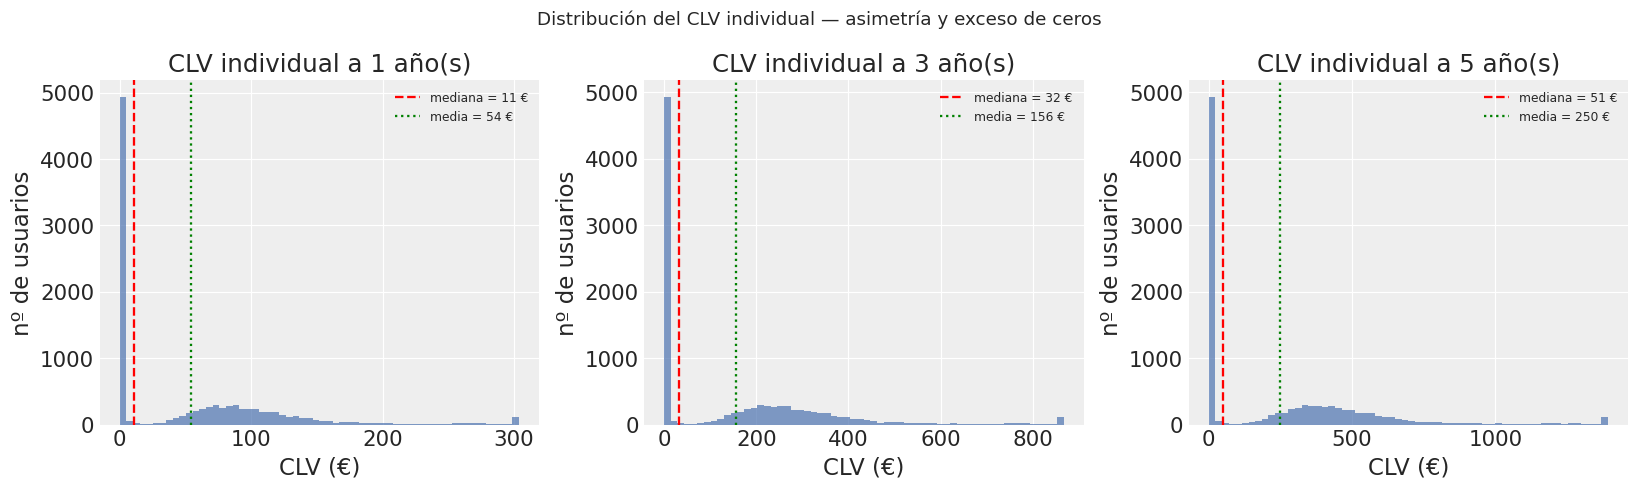

In [21]:
# Distribución del CLV mediano por usuario, para cada horizonte.
# Mostramos mediana (roja) y media (verde): la separación entre ambas es la
# firma de la asimetría — la media supera a la mediana por la cola de usuarios
# intensivos. La masa pegada a 0 son los usuarios ya abandonados.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (años, clv_da) in zip(axes, clv_posterior.items()):
    clv_med_user = clv_da.median(dim=("chain", "draw")).to_pandas()
    upper = clv_med_user.quantile(0.99)
    ax.hist(clv_med_user.clip(0, upper), bins=60, color="C0", alpha=0.7)
    ax.axvline(clv_med_user.median(), color="red", ls="--", lw=1.5,
               label=f"mediana = {clv_med_user.median():.0f} €")
    ax.axvline(clv_med_user.mean(), color="green", ls=":", lw=1.5,
               label=f"media = {clv_med_user.mean():.0f} €")
    ax.set_title(f"CLV individual a {años} año(s)")
    ax.set_xlabel("CLV (€)")
    ax.set_ylabel("nº de usuarios")
    ax.legend(fontsize=8)
plt.suptitle("Distribución del CLV individual — asimetría y exceso de ceros", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "clv_individual.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "clv_individual.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Segmentación: CLV por subpoblación

El objetivo específico (5) de la propuesta del TFM es comparar la dinámica de abandono y valor entre universitarios y residentes permanentes. Aquí lo materializamos con cortes del CLV por las tres variables categóricas del dataset: `tipo_titulo`, `cohort_year` y `es_joven`.

In [22]:
# clv_summary contiene una fila por usuario de la MUESTRA con sus variables
# originales (tipo_titulo, cohort_year, es_joven) + columnas de CLV.
customer_ids = data_analysis["customer_id"].values

clv_summary = rfm.set_index("customer_id").reindex(customer_ids).copy()
for años, clv_da in clv_posterior.items():
    series = clv_da.median(dim=("chain", "draw")).to_pandas().reindex(customer_ids)
    clv_summary[f"clv_{años}y"] = series.values
clv_summary["p_alive_med"] = p_alive_med.reindex(customer_ids).values

print(f"CLV calculado para muestra de {len(clv_summary):,} usuarios\n")

print("CLV a 5 años por tipo de título:")
print(clv_summary.groupby("tipo_titulo")["clv_5y"]
                  .agg(["median", "mean", "count"])
                  .round(2)
                  .sort_values("median", ascending=False))

print("\nCLV a 5 años por es_joven:")
print(clv_summary.groupby("es_joven")["clv_5y"]
                  .agg(["median", "mean", "count"])
                  .round(2))

print("\nCLV a 5 años por cohorte:")
print(clv_summary.groupby("cohort_year")["clv_5y"]
                  .agg(["median", "mean", "count"])
                  .round(2))

CLV calculado para muestra de 10,000 usuarios

CLV a 5 años por tipo de título:
                   median    mean  count
tipo_titulo                             
bono_30_dias       912.47  616.15    192
ocasional          574.24  632.24    607
tarjeta_consorcio   60.07  219.25   7903
monedero_metro       2.74  206.66   1298

CLV a 5 años por es_joven:
          median    mean  count
es_joven                       
False      50.99  241.07   8740
True       50.99  314.36   1260

CLV a 5 años por cohorte:
             median    mean  count
cohort_year                       
2018           0.00  213.83   4436
2019           0.00  214.53    639
2020          20.03  293.56    115
2021           0.00  266.27    865
2022         220.10  276.37   1291
2023         266.97  289.00   1321
2024         301.99  304.62    875
2025         315.60  323.61    458


C:\Users\andre\AppData\Local\Temp\ipykernel_36652\2297021470.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


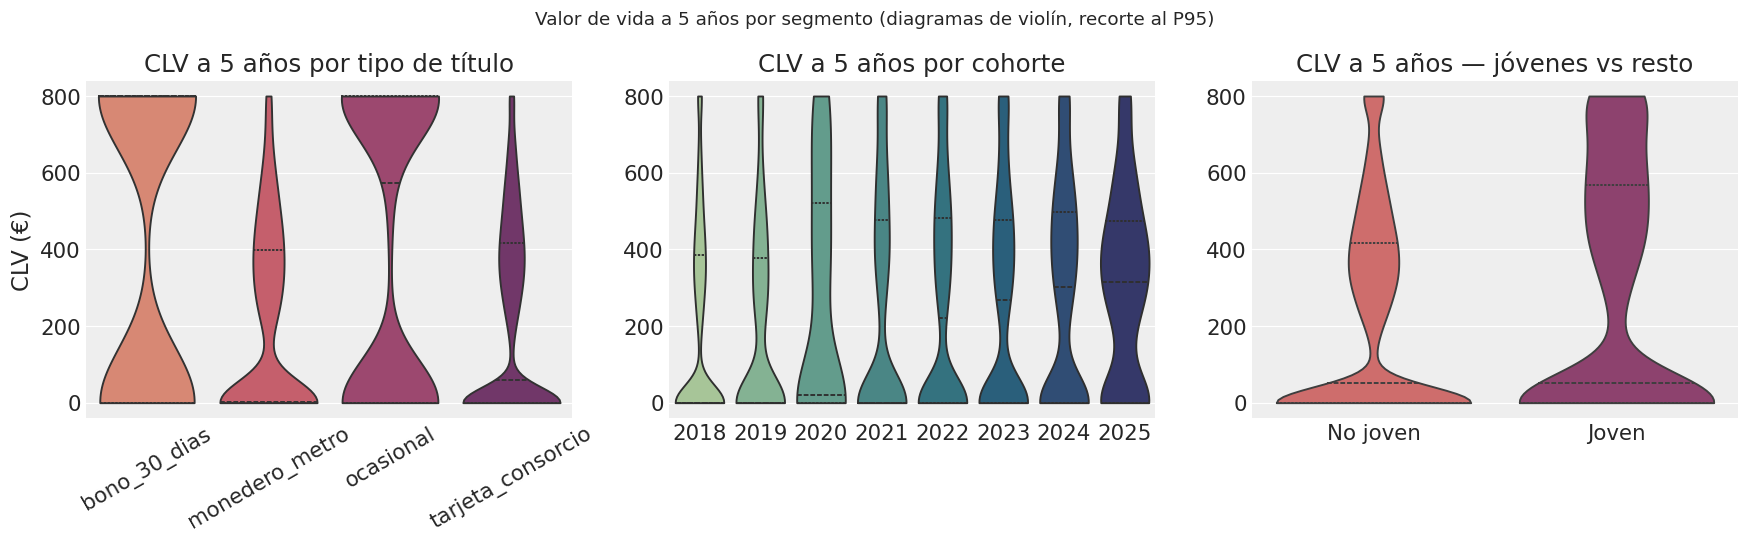

In [23]:
# Diagramas de violín del CLV a 5 años por segmento.
# El violín muestra la forma completa de la distribución —incluida la masa de
# usuarios inactivos cerca de 0 y la cola de intensivos—, más informativo que
# la caja. Recortamos al P95 para que la cola no aplaste la figura.
clip_hi = clv_summary["clv_5y"].quantile(0.95)
df_v = clv_summary.assign(
    clv_5y_clip=clv_summary["clv_5y"].clip(upper=clip_hi),
    grupo_joven=clv_summary["es_joven"].map({False: "No joven", True: "Joven"}),
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Por tipo de título — paleta cálida coherente con el rojo institucional
sns.violinplot(data=df_v, x="tipo_titulo", y="clv_5y_clip", ax=axes[0],
               hue="tipo_titulo", legend=False, palette="flare",
               cut=0, inner="quartile")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title("CLV a 5 años por tipo de título")
axes[0].set_ylabel("CLV (€)")
axes[0].set_xlabel("")

# (b) Por cohorte — paleta secuencial (la cohorte es ordinal)
sns.violinplot(data=df_v, x="cohort_year", y="clv_5y_clip", ax=axes[1],
               hue="cohort_year", legend=False, palette="crest",
               cut=0, inner="quartile")
axes[1].set_title("CLV a 5 años por cohorte")
axes[1].set_ylabel("")
axes[1].set_xlabel("")

# (c) Universitarios vs resto
sns.violinplot(data=df_v, x="grupo_joven", y="clv_5y_clip", ax=axes[2],
               order=["No joven", "Joven"], hue="grupo_joven", legend=False,
               palette="flare", cut=0, inner="quartile")
axes[2].set_title("CLV a 5 años — jóvenes vs resto")
axes[2].set_ylabel("")
axes[2].set_xlabel("")

plt.suptitle("Valor de vida a 5 años por segmento (diagramas de violín, recorte al P95)",
             fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "clv_5.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "clv_5.png", dpi=200, bbox_inches="tight")
plt.show()

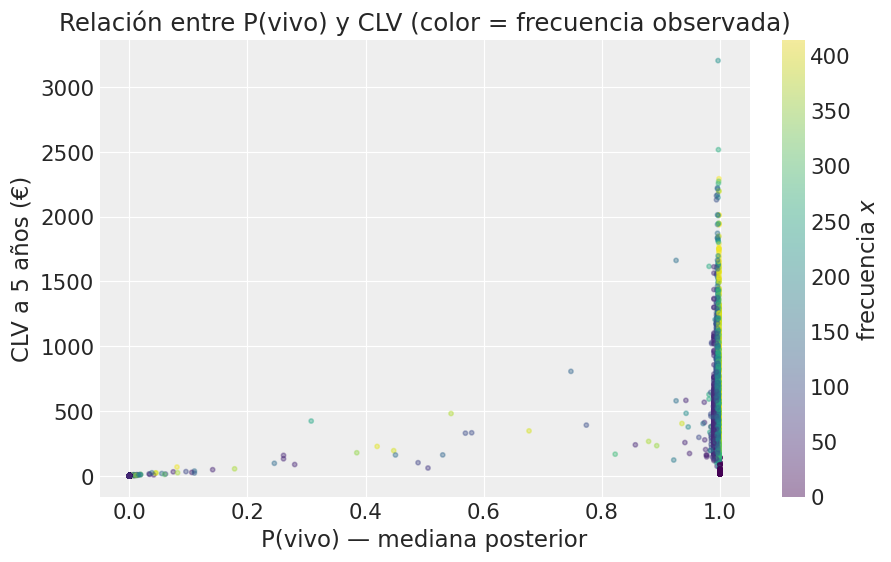

In [24]:
# P(vivo) vs CLV: los "vivos" valen más; los "muertos" tienen CLV bajo.
# Usamos constrained_layout porque la barra de color añade un eje que
# no se lleva bien con plt.tight_layout().
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
sc = ax.scatter(clv_summary["p_alive_med"], clv_summary["clv_5y"],
                 c=clv_summary["frequency"], cmap="viridis",
                 alpha=0.4, s=8)
ax.set_xlabel("P(vivo) — mediana posterior")
ax.set_ylabel("CLV a 5 años (€)")
ax.set_title("Relación entre P(vivo) y CLV (color = frecuencia observada)")
fig.colorbar(sc, ax=ax, label="frecuencia $x$")
plt.show()